# Cookbook 2: compare metadata-defined populations

This recipe builds a pretend 12-sample VCF containing two six-sample populations. It uses metadata to define the groups, draws four diploids repeatedly within each group, and compares their inferred selfing rates. The populations have true simulated selfing rates of `0.20` and `0.75`.

In [1]:
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Create a grouped teaching dataset

At each site, each population receives genotypes sampled from its own DGS distribution. **The sample IDs in the metadata exactly match the VCF header**, which is the main requirement for real metadata files.

The generator assigns genotypes independently at each site. It demonstrates
grouping and parsing, not biological variation among fixed individuals with
shared selfing histories. Use the SLiM recipe for biological validation.

In [2]:
from selfdgs import dgs_probabilities

rng = np.random.default_rng(23)
populations = {'low_selfing': 0.20, 'high_selfing': 0.75}
samples_by_population = {
    population: [f'{population}_{i}' for i in range(1, 7)]
    for population in populations
}
metadata = pd.DataFrame([
    {'sample': sample, 'population': population}
    for population, samples in samples_by_population.items()
    for sample in samples
])
metadata

,sample,population
0,low_selfing_1,low_selfing
1,low_selfing_2,low_selfing
2,low_selfing_3,low_selfing
3,low_selfing_4,low_selfing
4,low_selfing_5,low_selfing
5,low_selfing_6,low_selfing
6,high_selfing_1,high_selfing
7,high_selfing_2,high_selfing
8,high_selfing_3,high_selfing
9,high_selfing_4,high_selfing


In [3]:
def draw_genotypes(selfing_rate, n_diploids):
    probabilities = dgs_probabilities(selfing_rate, n_diploids=n_diploids)
    configs = list(probabilities)
    weights = [probabilities[config] for config in configs]
    n0, n1, n2 = configs[rng.choice(len(configs), p=weights)]
    genotypes = ['0/0'] * n0 + ['0/1'] * n1 + ['1/1'] * n2
    rng.shuffle(genotypes)
    return genotypes

all_samples = metadata['sample'].tolist()
lines = ['##fileformat=VCFv4.2', '##contig=<ID=1>', '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">', '#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\t' + '\t'.join(all_samples)]
n_sites = 1_000
for position in range(1, n_sites + 1):
    genotypes = []
    for population, selfing_rate in populations.items():
        genotypes.extend(draw_genotypes(selfing_rate, 6))
    lines.append(f'1\t{position}\t.\tA\tG\t.\tPASS\t.\tGT\t' + '\t'.join(genotypes))
vcf_path = Path(tempfile.mkdtemp()) / 'grouped_teaching.vcf'
vcf_path.write_text('\n'.join(lines) + '\n')
print(f'{len(all_samples)} samples in {len(populations)} populations; {n_sites:,} sites')

12 samples in 2 populations; 1,000 sites


## Audit groups and construct draws

Inspect the audit before fitting to make sure it is doing what you think it should be doing. Doing so can help you catch misspelled IDs, missing VCF samples, and groups too small for the requested draw size. The manifest records the samples and an independent random seed for every draw, so any row can be regenerated from its displayed seed.

In [4]:
from selfdgs import read_vcf_samples
from selfdgs.empirical import make_draw_manifest, make_sample_groups

vcf_samples = read_vcf_samples(vcf_path)
sample_audit, groups = make_sample_groups(
    vcf_samples, mode='grouped', metadata=metadata,
    sample_column='sample', group_column='population', min_samples=4,
)
display(sample_audit)
manifest = make_draw_manifest(groups, n_diploids=4, n_draws=20, seed=101)
manifest[['group', 'draw_id', 'seed', 'sample_ids']].head(8)

,group,n_samples,metadata_n,in_vcf_n,missing_from_vcf_n,included
0,high_selfing,6,6,6,0,True
1,low_selfing,6,6,6,0,True


,group,draw_id,seed,sample_ids
0,high_selfing,0,9468529083658986497,high_selfing_5;high_selfing_1;high_selfing_4;h...
1,high_selfing,1,13484087698725140722,high_selfing_2;high_selfing_3;high_selfing_1;h...
2,high_selfing,2,4828512485993340625,high_selfing_6;high_selfing_2;high_selfing_4;h...
3,high_selfing,3,1049749867354164436,high_selfing_6;high_selfing_1;high_selfing_3;h...
4,high_selfing,4,12282225567100967624,high_selfing_6;high_selfing_5;high_selfing_3;h...
5,high_selfing,5,9872225493476784661,high_selfing_3;high_selfing_6;high_selfing_5;h...
6,high_selfing,6,12999290839060122675,high_selfing_1;high_selfing_4;high_selfing_6;h...
7,high_selfing,7,14175342004395415625,high_selfing_4;high_selfing_5;high_selfing_6;h...


## Count, fit, and inspect diagnostics

In [5]:
from selfdgs.empirical import aggregate_fit_summary, dgs_for_draws, fit_draws

counts_by_draw, site_diagnostics, draw_diagnostics = dgs_for_draws(
    vcf_path, manifest, mode='folded', polarization='folded',
)
fit_summary, likelihood_curves, fit_counts_by_draw = fit_draws(
    counts_by_draw, n_diploids=4, mode='folded',
    input_polarization='folded', s_grid=np.linspace(0, 0.98, 50),
    low_polymorphic_site_threshold=50,
)
fit_summary[['group', 'draw_id', 'best_s', 'n_fit_sites', 'support_lower', 'support_upper', 'warnings']].head(10)

,group,draw_id,best_s,n_fit_sites,support_lower,support_upper,warnings
0,high_selfing,0,0.76,837,0.74,0.76,
1,high_selfing,1,0.76,812,0.76,0.78,
2,high_selfing,2,0.76,825,0.76,0.78,
3,high_selfing,3,0.76,803,0.74,0.78,
4,high_selfing,4,0.76,802,0.76,0.78,
5,high_selfing,5,0.76,802,0.76,0.78,
6,high_selfing,6,0.76,840,0.74,0.76,
7,high_selfing,7,0.76,827,0.74,0.78,
8,high_selfing,8,0.76,834,0.76,0.78,
9,high_selfing,9,0.76,812,0.76,0.78,


In [6]:
diagnostic_summary = draw_diagnostics.groupby('group', as_index=False).agg(
    retained_sites=('retained_sites', 'min'),
    missing_genotypes=('missing_genotype', 'max'),
    malformed_genotypes=('malformed_genotype', 'max'),
)
diagnostic_summary

,group,retained_sites,missing_genotypes,malformed_genotypes
0,high_selfing,1000,0,0
1,low_selfing,1000,0,0


## Compare populations

The group table summarizes variation across fixed-size draws. This basically measures sensitivity to sample choice (the quantiles are not confidence intervals).

In [7]:
group_summary = aggregate_fit_summary(fit_summary)
group_summary.insert(1, 'generating_s', group_summary['group'].map(populations))
group_summary

,group,generating_s,n_fit_draws,median_best_s,mean_best_s,q025_best_s,q975_best_s,median_n_fit_sites
0,high_selfing,0.75,20,0.76,0.760,0.76,0.76,826.0
1,low_selfing,0.20,20,0.22,0.225,0.20,0.24,860.0


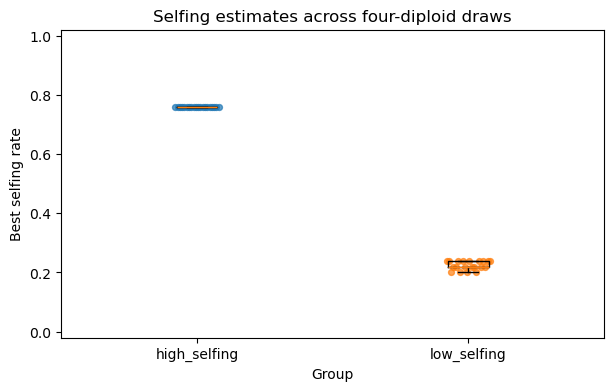

In [8]:
from selfdgs.plotting import plot_best_s_distribution

fig = plot_best_s_distribution(fit_summary)
fig.axes[0].set_title('Selfing estimates across four-diploid draws')
plt.show()